In [16]:
import os
import time
import importlib
import nest_asyncio
import featureExtractor as ext

# 주피터 노트북에서 이벤트 루프 재진입을 가능하게 함
nest_asyncio.apply()

importlib.reload(ext)

dataset = "FSD50K.eval_audio"
# 폴더 선택 다이얼로그 표시
selected_directory = f"./{dataset}"
features_pkl_path = f"./{dataset}_features.pkl"

if not selected_directory:
    print("Folder selection cancelled.")
else:
    # 현재 시간 가져오기
    current_time = time.strftime("%Y%m%d-%H%M%S")

    # 선택한 폴더명 추출
    folder_name = os.path.basename(os.path.normpath(selected_directory))
    file_name = f"{folder_name}"
    print(f"Processing folder: {selected_directory}")
    print(f"Generated file name: {file_name}")

    # 오디오 파일 읽어서 buffers 생성
    buffers = ext.readfile(selected_directory, file_name, detect_onset=True)

Processing folder: ./FSD50K.eval_audio
Generated file name: FSD50K.eval_audio
Loaded 10730 buffers from FSD50K.eval_audio.pkl.
readfile 처리 시간: 0.47초


In [17]:
import pickle

try:
    with open(features_pkl_path, 'rb') as f:
        features = pickle.load(f)
except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: {features_pkl_path}")
    exit()

print(f"총 오디오 유닛 개수: {len(features)}\n")

if features and isinstance(features, list) and isinstance(features[0], dict):
    first_feature = features[0]
    print("첫번째 오디오 유닛의 메타데이터 구조:")
    for key, value in first_feature.items():
        print(f"  {key}: {value}")
else:
    print("불러온 데이터의 구조가 예상과 다릅니다.")

총 오디오 유닛 개수: 10730

첫번째 오디오 유닛의 메타데이터 구조:
  filename: 399190_onset_5.wav
  mfccs_mean: [-443.7132873535156, 15.04551887512207, -30.942747116088867, -35.71137237548828, -29.968225479125977, 26.793973922729492, 48.58819580078125, -1.7060816287994385, -20.505762100219727, -18.723058700561523, -15.754990577697754, 22.72562599182129, 16.282442092895508]
  spectral_centroid_mean: 1300.5331711895244
  chroma_mean: [1.0, 0.5028490424156189, 0.06332018971443176, 0.0013303246814757586, 0.0008259228779934347, 0.008162979036569595, 0.008280443958938122, 0.00076869543408975, 0.0009429857018403709, 0.0010605700081214309, 0.02555146999657154, 0.3531169593334198]


Spectral Centroid (Graph)

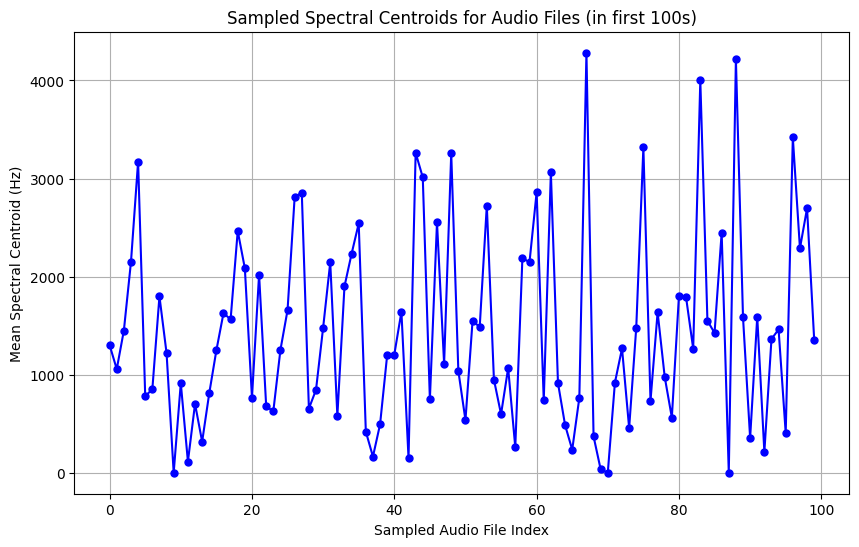

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

try:
    with open(features_pkl_path, 'rb') as f:
        features_list = pickle.load(f)
except FileNotFoundError:
    print(f"File {features_pkl_path} not found.")
    features_list = []

# Extract the spectral centroid values from the features list
centroids_list = []
for feature_data in features_list:
    spectral_centroid_mean = feature_data.get('spectral_centroid_mean')
    if spectral_centroid_mean is not None:
        centroids_list.append(spectral_centroid_mean)

# Check if there are any valid centroids to plot
if not centroids_list:
    print("No valid audio files found or processed.")
else:
    # Convert the list of spectral centroids to a NumPy array
    centroids_array = np.array(centroids_list).reshape(-1, 1)

    # Optional: Reduce the number of data points by sampling
    sample_size = min(100, len(centroids_array))  # Limit to 100 samples
    indices = np.linspace(0, len(centroids_array) - 1, sample_size).astype(int)
    sampled_centroids = centroids_array[indices]

    # Plotting the sampled spectral centroids
    plt.figure(figsize=(10, 6))
    plt.plot(sampled_centroids, marker='o', linestyle='-', color='b', markersize=5)
    plt.title('Sampled Spectral Centroids for Audio Files (in first 100s)')
    plt.xlabel('Sampled Audio File Index')
    plt.ylabel('Mean Spectral Centroid (Hz)')
    plt.grid(True)
    plt.show()


t-SNE'd MFCC Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm  # tqdm 임포트
from sklearn.decomposition import PCA  # 추가: sklearn.decomposition에서 PCA 임포트
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

try:
    with open(features_pkl_path, 'rb') as f:
        features_list = pickle.load(f)
except FileNotFoundError:
    print(f"File {features_pkl_path} not found.")
    features_list = []

# 리스트에 3가지 오디오 설명자를 결합한 값을 저장
descriptors_list = []

# 3가지 설명자 키 (featureExtractor.py에 정의된 키 사용)
desc_keys = ['mfccs_mean', 'spectral_centroid_mean', 'chroma_mean']

# Extract and combine descriptors for each audio unit
for idx, feature_data in enumerate(tqdm(features_list, desc='Extracting descriptors')):
    combined = []
    valid = True
    for key in desc_keys:
        data = feature_data.get(key)
        if data is None:
            valid = False
            break
        arr = np.array(data)
        # 만약 스칼라(0차원)라면 1차원 배열로 변환
        if arr.ndim == 0:
            arr = np.array([arr])
        # 2D 데이터인 경우 시간축 평균을 취함
        elif arr.ndim == 2:
            arr = np.mean(arr, axis=1)
        elif arr.ndim != 1:
            valid = False
            break
        combined.append(arr)
    if valid and len(combined) == len(desc_keys):
        # Concatenate the descriptors along axis 0
        combined_descriptor = np.concatenate(combined)
        descriptors_list.append(combined_descriptor)
    else:
        print(f"Skipping feature_data index {idx}: missing or invalid descriptors.")


# 모든 feature vector의 길이가 동일한지 확인 후 필터링
valid_descriptors = []
valid_indices = []  # 원본 인덱스 저장 리스트
target_len = None
for i, vec in enumerate(descriptors_list):
    vec = np.array(vec)
    if vec.size == 0:
        continue
    if target_len is None:
        target_len = vec.shape[0]
    if vec.shape[0] == target_len:
        valid_descriptors.append(vec)
        valid_indices.append(i)

descriptors_array = np.vstack(valid_descriptors)
# Perform t-SNE to reduce dimensionality to 3D (진행 상황은 TSNE 객체의 verbose 옵션을 통해 확인 가능)
tsne = TSNE(n_components=3, random_state=0, verbose=1)
descriptors_3d = tsne.fit_transform(descriptors_array)

# Normalize the 3D coordinates to fit in the range 0 to 1
min_vals = descriptors_3d.min(axis=0)
max_vals = descriptors_3d.max(axis=0)
descriptors_3d_normalized = (descriptors_3d - min_vals) / (max_vals - min_vals)

# ------------------------------------------------------------------
# [추가] t-SNE 임베딩에 대한 클러스터링 및 거리 분포 점수 계산
k = 10
kmeans_tsne = KMeans(n_clusters=k, random_state=0)
labels_tsne = kmeans_tsne.fit_predict(descriptors_3d_normalized)
sil_score_tsne = silhouette_score(descriptors_3d_normalized, labels_tsne)
print("Silhouette Score on t-SNE embedding:", sil_score_tsne)

tsne_distances = pdist(descriptors_3d_normalized)
mean_tsne_distance = np.mean(tsne_distances)
std_tsne_distance = np.std(tsne_distances)
print(f"t-SNE Euclidean distance: {mean_tsne_distance:.2f} (±{std_tsne_distance:.2f})")

Extracting descriptors: 100%|██████████| 10730/10730 [00:00<00:00, 336027.85it/s]

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10418 samples in 0.000s...


[t-SNE] Computed neighbors for 10418 samples in 0.099s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10418
[t-SNE] Computed conditional probabilities for sample 2000 / 10418
[t-SNE] Computed conditional probabilities for sample 3000 / 10418
[t-SNE] Computed conditional probabilities for sample 4000 / 10418
[t-SNE] Computed conditional probabilities for sample 5000 / 10418
[t-SNE] Computed conditional probabilities for sample 6000 / 10418
[t-SNE] Computed conditional probabilities for sample 7000 / 10418
[t-SNE] Computed conditional probabilities for sample 8000 / 10418
[t-SNE] Computed conditional probabilities for sample 9000 / 10418
[t-SNE] Computed conditional probabilities for sample 10000 / 10418
[t-SNE] Computed conditional probabilities for sample 10418 / 10418
[t-SNE] Mean sigma: 26.193509


KeyboardInterrupt: 

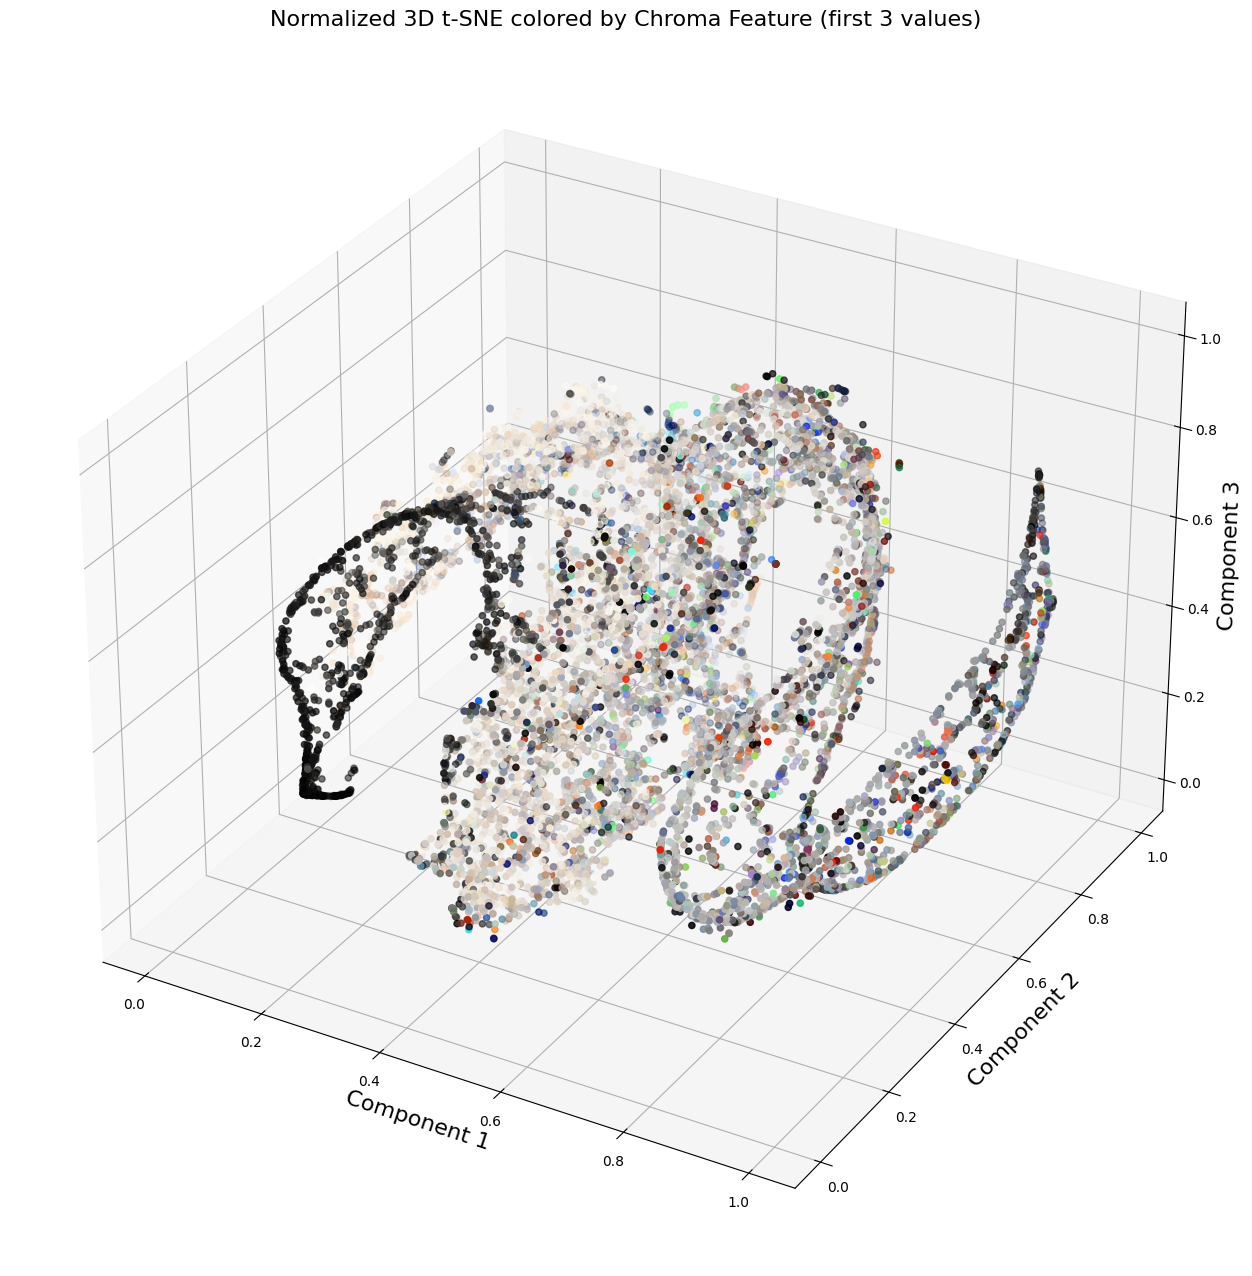

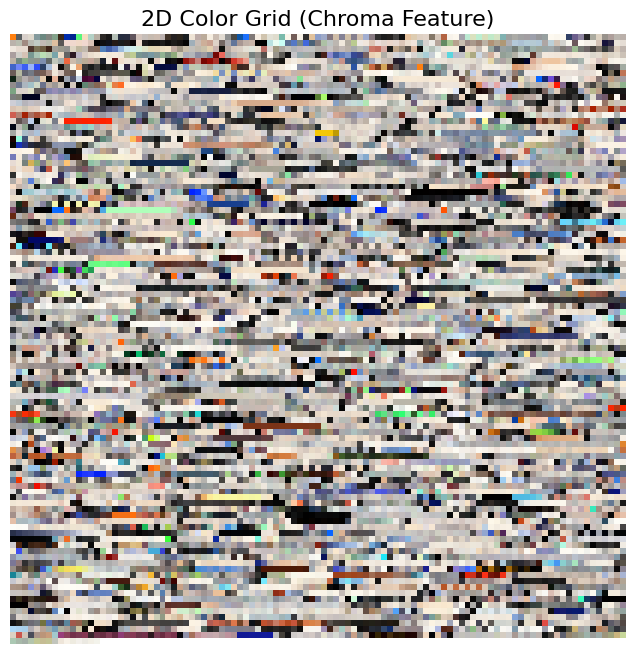

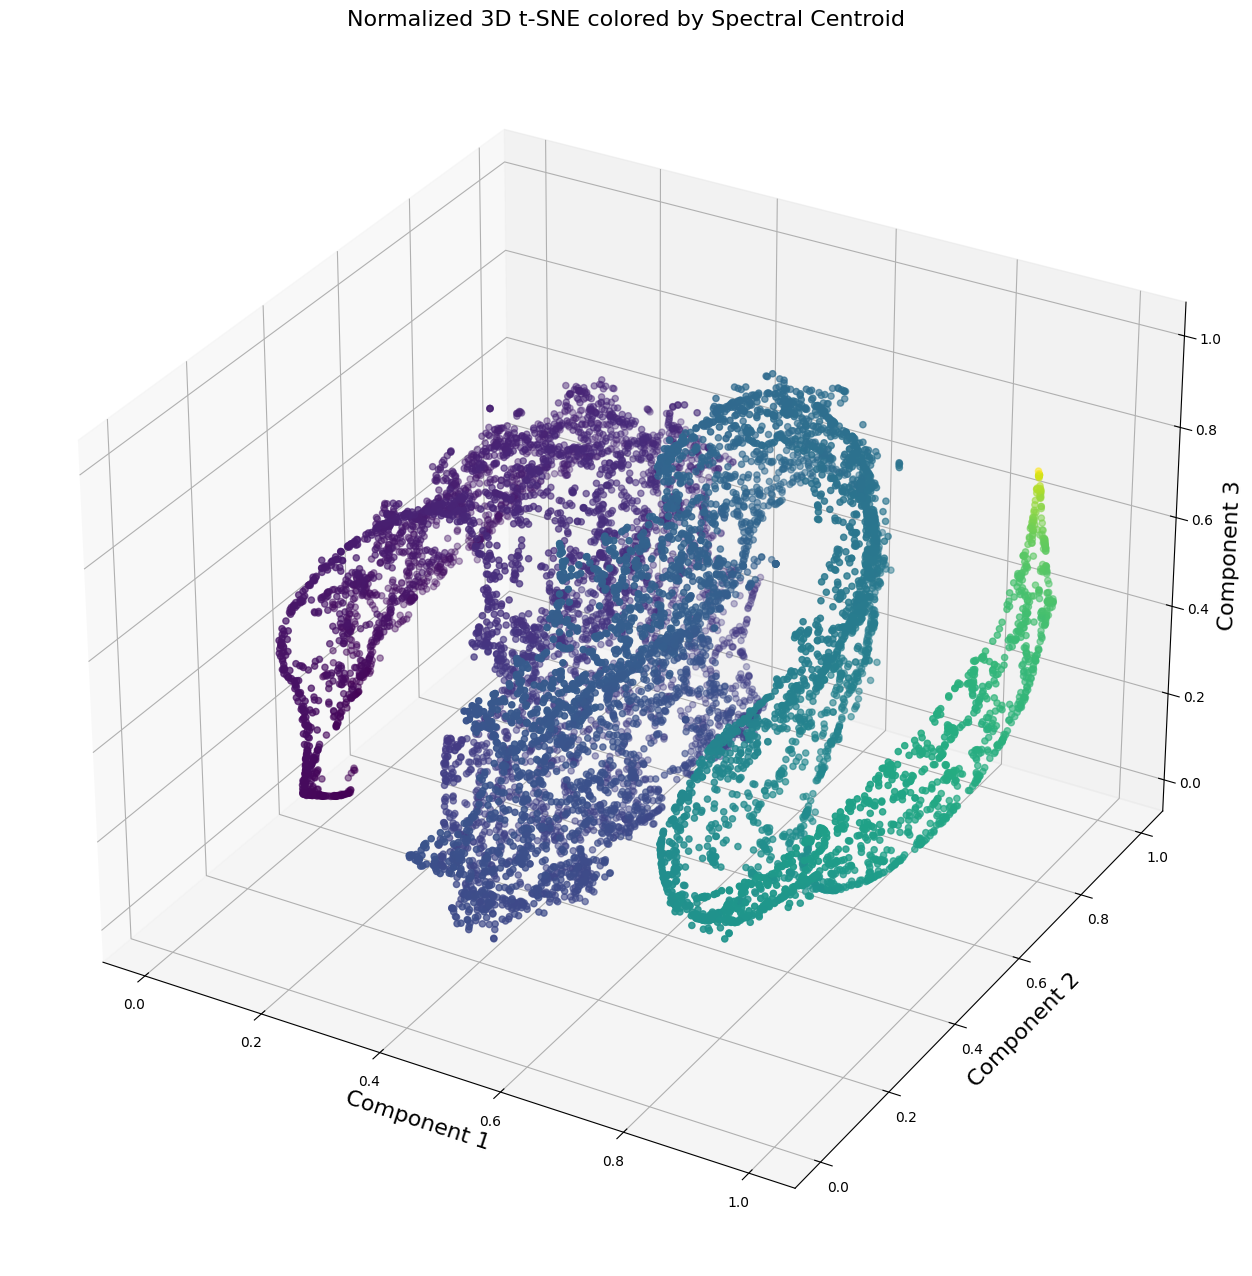

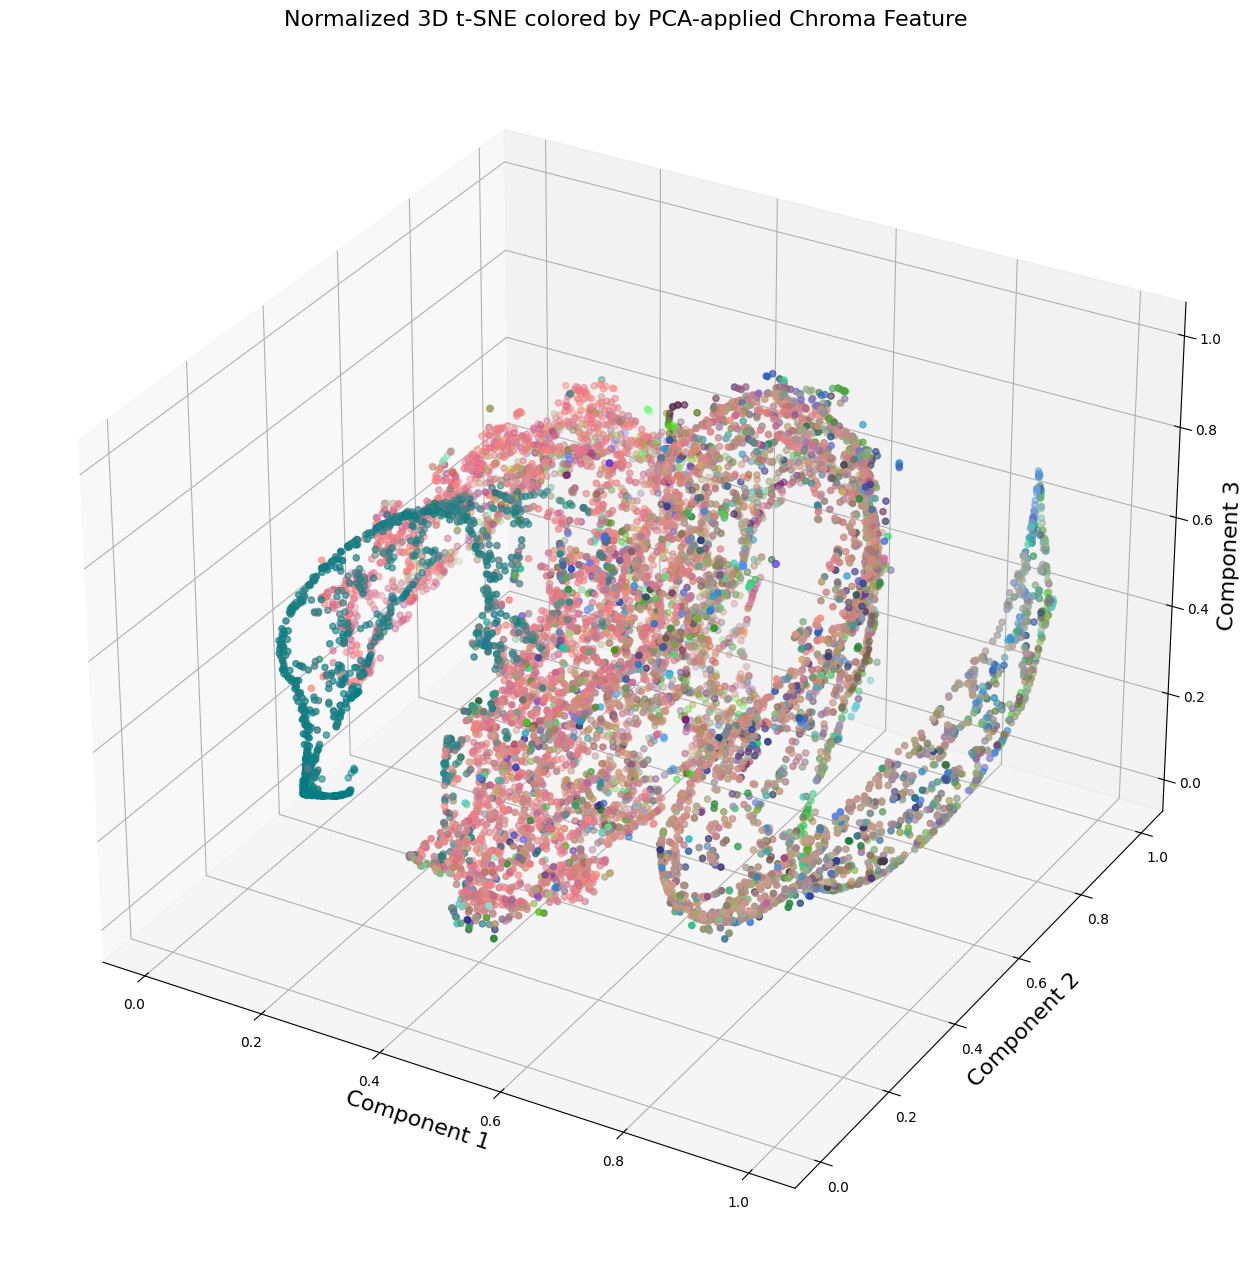

In [23]:
# Define a variable for font size
fontsize = 16

# ------------------------------------------------------------------
# 1. 색상 매핑: 크로마 피쳐 (chroma_mean)의 앞 3개 값을 RGB로 사용
chroma_colors = []
# valid_indices를 통해 원본 feature_data에 접근
for i in valid_indices:
    feature_data = features_list[i]
    chroma = np.array(feature_data.get('chroma_mean', []))
    # 크로마의 길이가 3 이상이면 앞 3개 요소로, 그렇지 않으면 0으로 패딩
    if (chroma.size >= 3):
        rgb = chroma[:3]
    else:
        rgb = np.pad(chroma, (0, 3 - chroma.size), mode='constant', constant_values=0)
    # 일반적으로 크로마 값은 이미 [0,1] 범위이지만, 혹시 모를 상황에 대비하여 clip
    rgb = np.clip(rgb, 0, 1)
    chroma_colors.append(rgb)
chroma_colors = np.array(chroma_colors)

# 3D scatter plot using chroma-based colors
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    descriptors_3d_normalized[:, 0],
    descriptors_3d_normalized[:, 1],
    descriptors_3d_normalized[:, 2],
    c=chroma_colors,
    marker='o'
)
ax.set_title('Normalized 3D t-SNE colored by Chroma Feature (first 3 values)', fontsize=fontsize)
ax.set_xlabel('Component 1', fontsize=fontsize)
ax.set_ylabel('Component 2', fontsize=fontsize)
ax.set_zlabel('Component 3', fontsize=fontsize)
plt.savefig('chroma_3d_scatter.png')
plt.show()

# 2D color grid for chroma-based colors
grid_size = int(np.ceil(np.sqrt(len(chroma_colors))))
padded_chroma = np.pad(
    chroma_colors,
    ((0, grid_size**2 - len(chroma_colors)), (0, 0)),
    mode='constant',
    constant_values=1.0
)
chroma_grid = padded_chroma.reshape((grid_size, grid_size, 3))
plt.figure(figsize=(8, 8))
plt.imshow(chroma_grid)
plt.title('2D Color Grid (Chroma Feature)', fontsize=fontsize)
plt.axis('off')
plt.savefig('chroma_2d_grid.png')
plt.show()

# ------------------------------------------------------------------
# 2. 색상 매핑: 스펙트럴 중심값 (spectral_centroid_mean)을 이용한 매핑
spectral_values = []
for i in valid_indices:
    feature_data = features_list[i]
    spec = feature_data.get('spectral_centroid_mean', 0.0)
    spectral_values.append(spec)
spectral_values = np.array(spectral_values)
# 스펙트럴 중심값 normalize (0~1)
spec_min, spec_max = spectral_values.min(), spectral_values.max()
spectral_norm = (spectral_values - spec_min) / (spec_max - spec_min)
# viridis colormap 적용
cmap = plt.cm.viridis
spectral_colors = cmap(spectral_norm)[:, :3]

# 3D scatter plot using spectral centroid based colors
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    descriptors_3d_normalized[:, 0],
    descriptors_3d_normalized[:, 1],
    descriptors_3d_normalized[:, 2],
    c=spectral_colors,
    marker='o'
)
ax.set_title('Normalized 3D t-SNE colored by Spectral Centroid', fontsize=fontsize)
ax.set_xlabel('Component 1', fontsize=fontsize)
ax.set_ylabel('Component 2', fontsize=fontsize)
ax.set_zlabel('Component 3', fontsize=fontsize)
plt.savefig('spectral_3d_scatter.png')
plt.show()

# 3. 색상 매핑 (PCA 적용한 크로마 벡터)
chroma_all = []
for i in valid_indices:
    feature_data = features_list[i]
    chroma = np.array(feature_data.get('chroma_mean', []))
    if chroma.size < 12:
        chroma = np.pad(chroma, (0, 12 - chroma.size), mode='constant', constant_values=0)
    elif chroma.size > 12:
        chroma = chroma[:12]
    chroma_all.append(chroma)
chroma_all = np.array(chroma_all)

pca = PCA(n_components=3)
chroma_pca = pca.fit_transform(chroma_all)
min_vals_pca = chroma_pca.min(axis=0)
max_vals_pca = chroma_pca.max(axis=0)
chroma_pca_normalized = (chroma_pca - min_vals_pca) / (max_vals_pca - min_vals_pca)

# 3D scatter plot: t-SNE 결과에 PCA로 얻은 크로마 색상 적용
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    descriptors_3d_normalized[:, 0],
    descriptors_3d_normalized[:, 1],
    descriptors_3d_normalized[:, 2],
    c=chroma_pca_normalized,
    marker='o'
)
ax.set_title('Normalized 3D t-SNE colored by PCA-applied Chroma Feature', fontsize=fontsize)
ax.set_xlabel('Component 1', fontsize=fontsize)
ax.set_ylabel('Component 2', fontsize=fontsize)
ax.set_zlabel('Component 3', fontsize=fontsize)
plt.savefig('pca_chroma_3d_scatter.png')
plt.show()

# # 2D 색상 그리드 (PCA 색상)
# grid_size = int(np.ceil(np.sqrt(len(chroma_pca_normalized))))
# padded_pca = np.pad(
#     chroma_pca_normalized,
#     ((0, grid_size**2 - len(chroma_pca_normalized)), (0, 0)),
#     mode='constant',
#     constant_values=1.0
# )
# pca_grid = padded_pca.reshape((grid_size, grid_size, 3))
# plt.figure(figsize=(8, 8))
# plt.imshow(pca_grid)
# plt.title('2D Color Grid (PCA-applied Chroma Feature)')
# plt.axis('off')
# plt.savefig('pca_chroma_2d_grid.png')
# plt.show()

Plotting lines:   0%|          | 0/329466 [00:00<?, ?it/s]

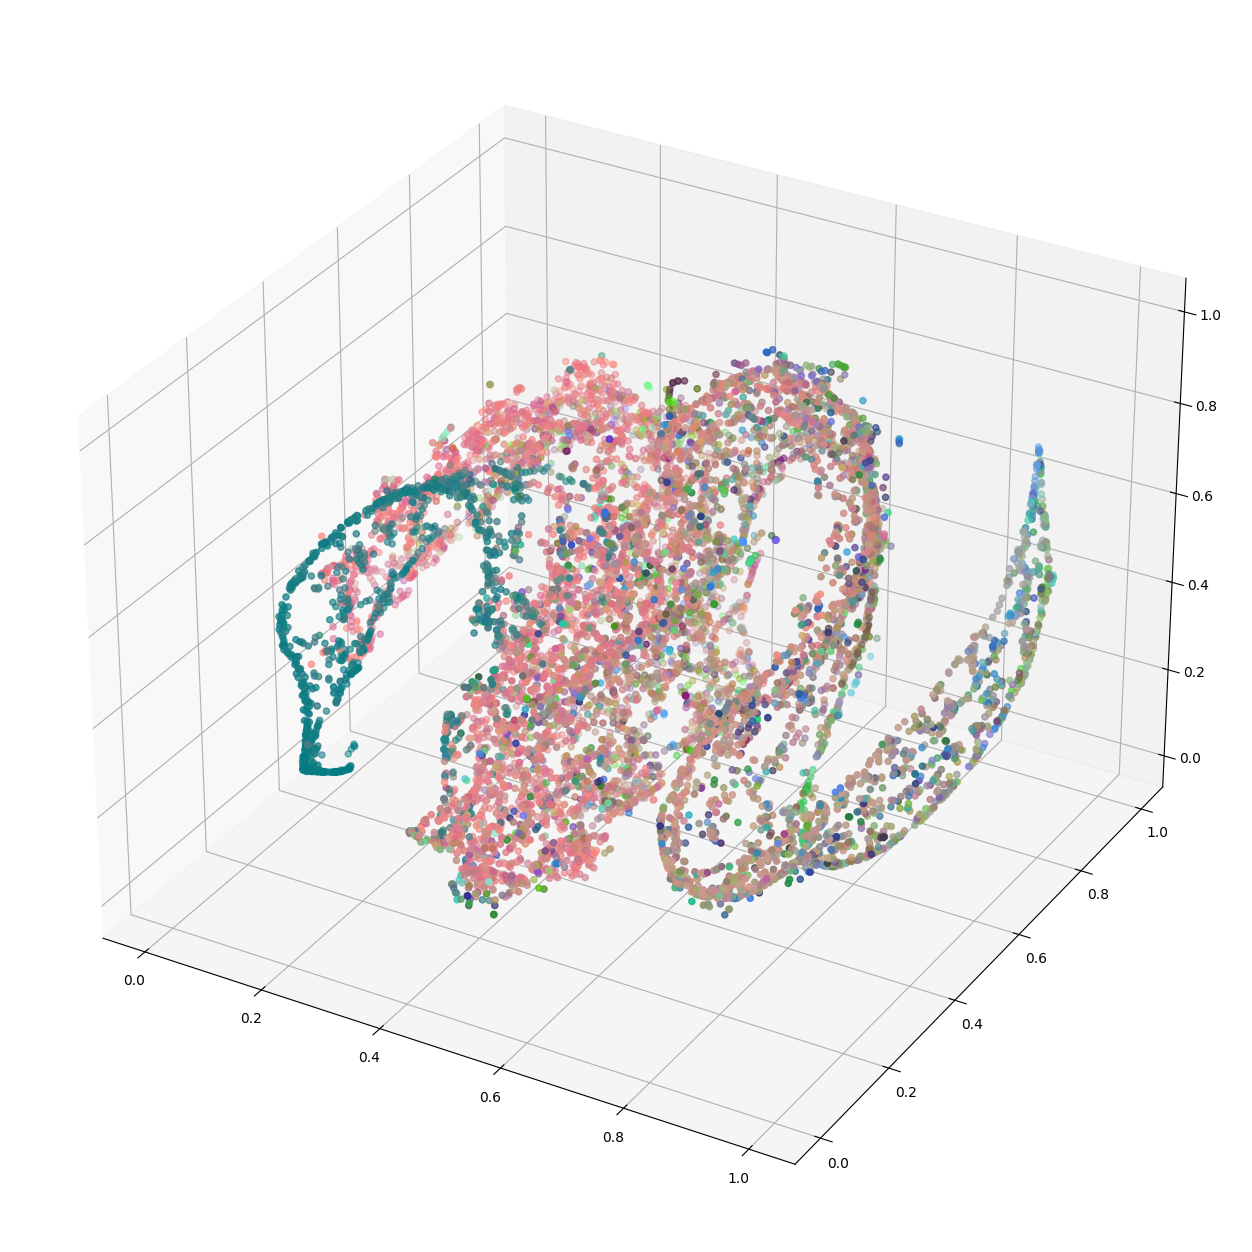

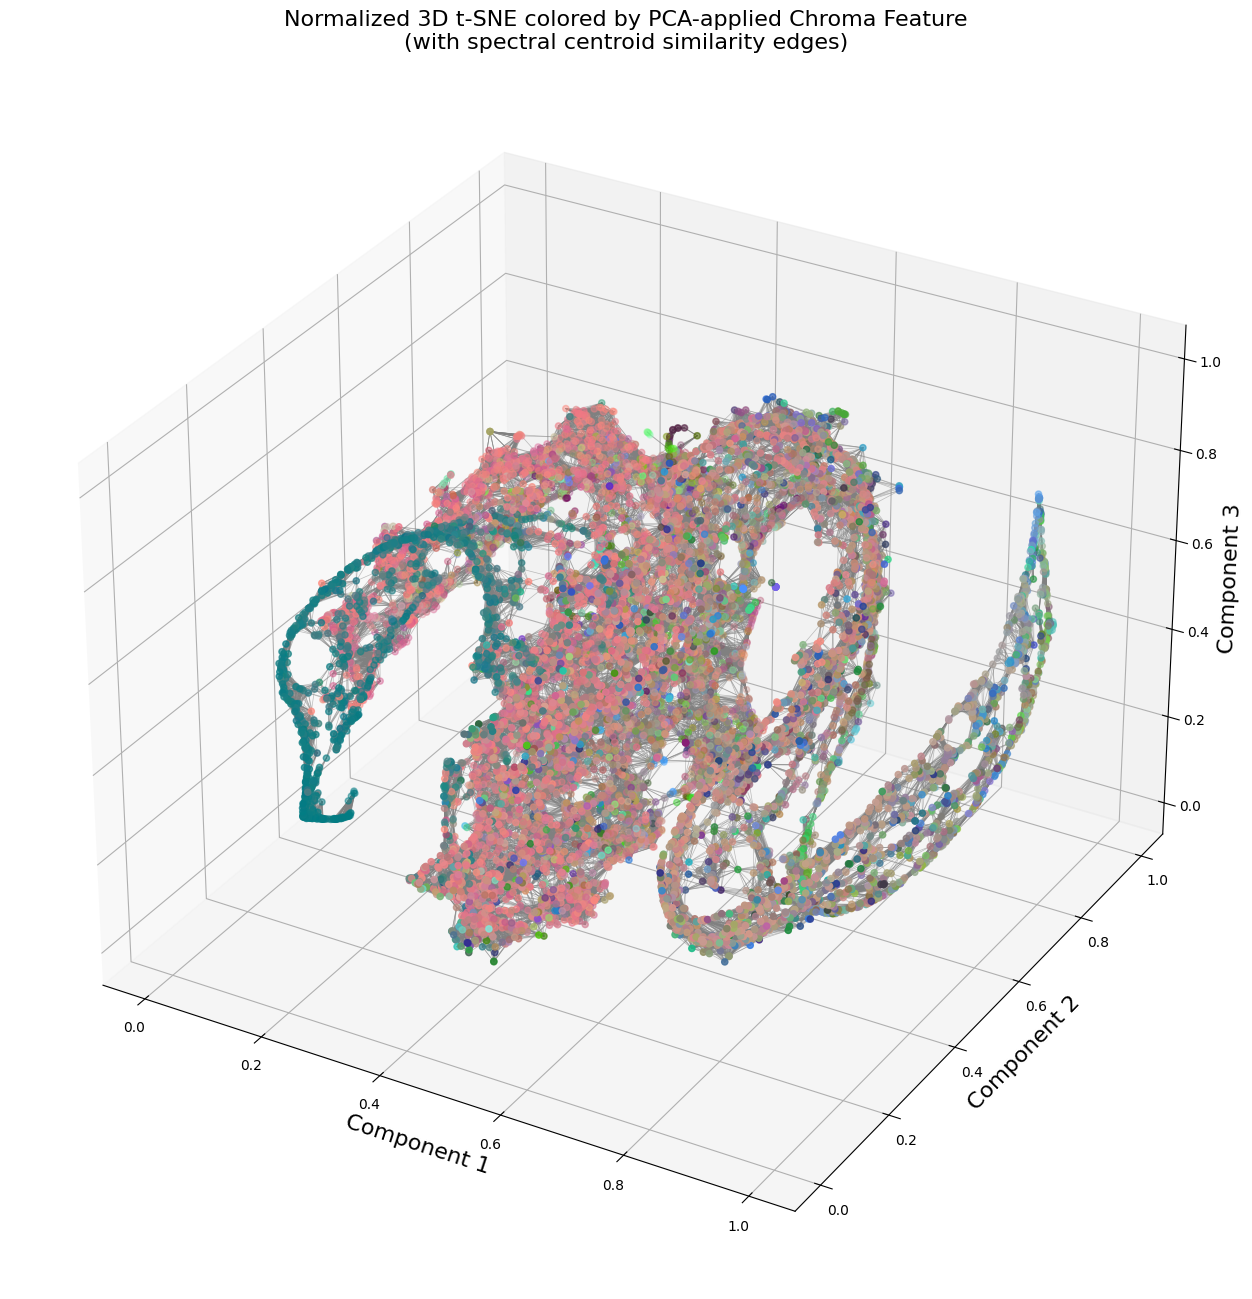

In [ ]:
from sklearn.decomposition import PCA  # PCA를 사용하여 차원 축소
from scipy.spatial.distance import pdist, squareform  # 거리 계산을 위한 함수들
from tqdm.auto import tqdm  # 진행 상황을 시각적으로 보여주는 라이브러리

# valid_indices를 이용해 각 오디오 유닛의 12차원 크로마 벡터를 수집
chroma_all = []
for i in tqdm(valid_indices, desc='Collecting chroma vectors'):  # 진행 상황을 표시하며 반복
    feature_data = features_list[i]  # 각 오디오 유닛의 feature 데이터 가져오기
    chroma = np.array(feature_data.get('chroma_mean', []))  # 크로마 벡터 가져오기
    # 12차원 크로마 벡터가 아닐 경우 12차원으로 패딩하거나 잘라냄
    if chroma.size < 12:
        chroma = np.pad(chroma, (0, 12 - chroma.size), mode='constant', constant_values=0)  # 패딩
    elif chroma.size > 12:
        chroma = chroma[:12]  # 자르기
    chroma_all.append(chroma)  # 리스트에 추가
chroma_all = np.array(chroma_all)  # numpy 배열로 변환

# PCA를 적용하여 3차원으로 축소 및 normalize
pca = PCA(n_components=3)  # PCA 객체 생성 (3차원으로 축소)
chroma_pca = pca.fit_transform(chroma_all)  # PCA 적용
min_vals = chroma_pca.min(axis=0)  # 각 차원의 최소값 계산
max_vals = chroma_pca.max(axis=0)  # 각 차원의 최대값 계산
chroma_pca_normalized = (chroma_pca - min_vals) / (max_vals - min_vals)  # 0~1 사이로 정규화

# 스펙트럴 중심값도 valid_indices로부터 수집 후 normalize (0~1)
spectral_values = []
for i in tqdm(valid_indices, desc='Collecting spectral centroid values'):  # 진행 상황을 표시하며 반복
    feature_data = features_list[i]  # 각 오디오 유닛의 feature 데이터 가져오기
    spec = feature_data.get('spectral_centroid_mean', 0.0)  # 스펙트럴 중심값 가져오기
    spectral_values.append(spec)  # 리스트에 추가
spectral_values = np.array(spectral_values)  # numpy 배열로 변환
spec_min, spec_max = spectral_values.min(), spectral_values.max()  # 최소값과 최대값 계산
spectral_norm = (spectral_values - spec_min) / (spec_max - spec_min)  # 0~1 사이로 정규화

# 선분 조건: t-SNE 공간상의 유클리드 거리와 스펙트럴 중심 정규화 값 차이가 모두 일정 임계치 이하인 경우
threshold_tsne = 0.05   # t-SNE 좌표 상의 거리 임계치 (0~1 기준)
threshold_spec = 0.1    # 스펙트럴 중심 정규화 값 차이 임계치

# pairwise t-SNE 거리와 스펙트럴 중심 차이 행렬 계산
tsne_dists = squareform(pdist(descriptors_3d_normalized))  # t-SNE 좌표 상의 거리 계산
spec_diffs = squareform(pdist(spectral_norm.reshape(-1, 1), metric='cityblock'))  # 스펙트럴 중심 차이 계산

# 3D scatter plot: t-SNE 결과의 위치에 PCA로 얻은 크로마 색상을 적용
fig = plt.figure(figsize=(16, 16))  # 그림 크기 설정
ax = fig.add_subplot(111, projection='3d')  # 3D 서브플롯 추가
ax.scatter(
    descriptors_3d_normalized[:, 0],  # x 좌표
    descriptors_3d_normalized[:, 1],  # y 좌표
    descriptors_3d_normalized[:, 2],  # z 좌표
    c=chroma_pca_normalized,  # 색상
    marker='o'  # 마커 모양
)

# 두 조건을 만족하는 인덱스 쌍 검색 (중복 제거를 위해 i < j)
pairs = np.where((tsne_dists < threshold_tsne) & (spec_diffs < threshold_spec))  # 조건을 만족하는 인덱스 쌍 찾기
for i, j in tqdm(zip(pairs[0], pairs[1]), desc='Plotting lines', total=len(pairs[0])):  # 진행 상황을 표시하며 반복
    if i < j:  # 중복 제거
        xs = [descriptors_3d_normalized[i, 0], descriptors_3d_normalized[j, 0]]  # x 좌표
        ys = [descriptors_3d_normalized[i, 1], descriptors_3d_normalized[j, 1]]  # y 좌표
        zs = [descriptors_3d_normalized[i, 2], descriptors_3d_normalized[j, 2]]  # z 좌표
        ax.plot(xs, ys, zs, c='gray', alpha=0.5, linewidth=0.5)  # 선 그리기

ax.set_title('Normalized 3D t-SNE colored by PCA-applied Chroma Feature\n(with spectral centroid similarity edges)', fontsize=fontsize)  # 제목 설정
ax.set_xlabel('Component 1', fontsize=fontsize)  # x축 라벨 설정
ax.set_ylabel('Component 2', fontsize=fontsize)  # y축 라벨 설정
ax.set_zlabel('Component 3', fontsize=fontsize)  # z축 라벨 설정
plt.show()  # 그래프 표시


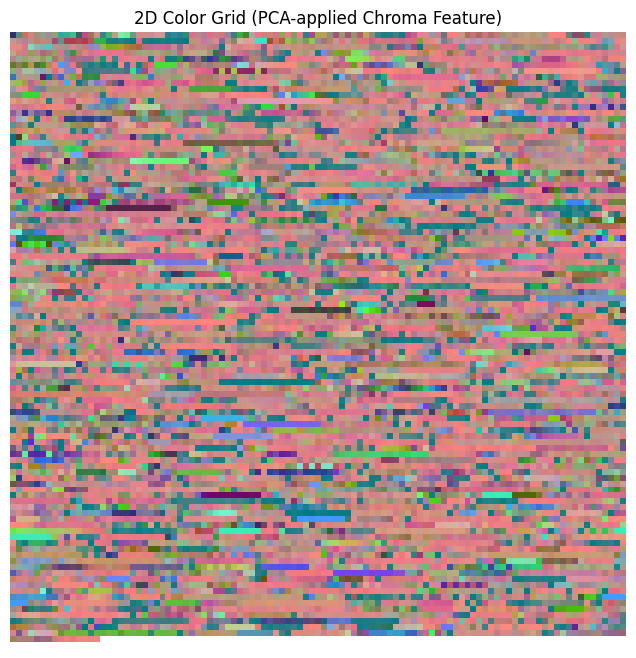

In [ ]:


# 2D 색상 그리드 (PCA 적용 크로마 색상)
grid_size = int(np.ceil(np.sqrt(len(chroma_pca_normalized))))
padded_pca = np.pad(
    chroma_pca_normalized,
    ((0, grid_size**2 - len(chroma_pca_normalized)), (0, 0)),
    mode='constant',
    constant_values=1.0
)
pca_grid = padded_pca.reshape((grid_size, grid_size, 3))
plt.figure(figsize=(8, 8))
plt.imshow(pca_grid)
plt.title('2D Color Grid (PCA-applied Chroma Feature)')
plt.axis('off')
plt.show()

Extracting composite descriptors: 100%|██████████| 10730/10730 [00:00<00:00, 315701.88it/s]
/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_components=3, n_jobs=1, random_state=42, verbose=True)
Tue Mar  4 15:02:12 2025 Construct fuzzy simplicial set
Tue Mar  4 15:02:14 2025 Finding Nearest Neighbors
Tue Mar  4 15:02:15 2025 Finished Nearest Neighbor Search
Tue Mar  4 15:02:15 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Mar  4 15:02:17 2025 Finished embedding


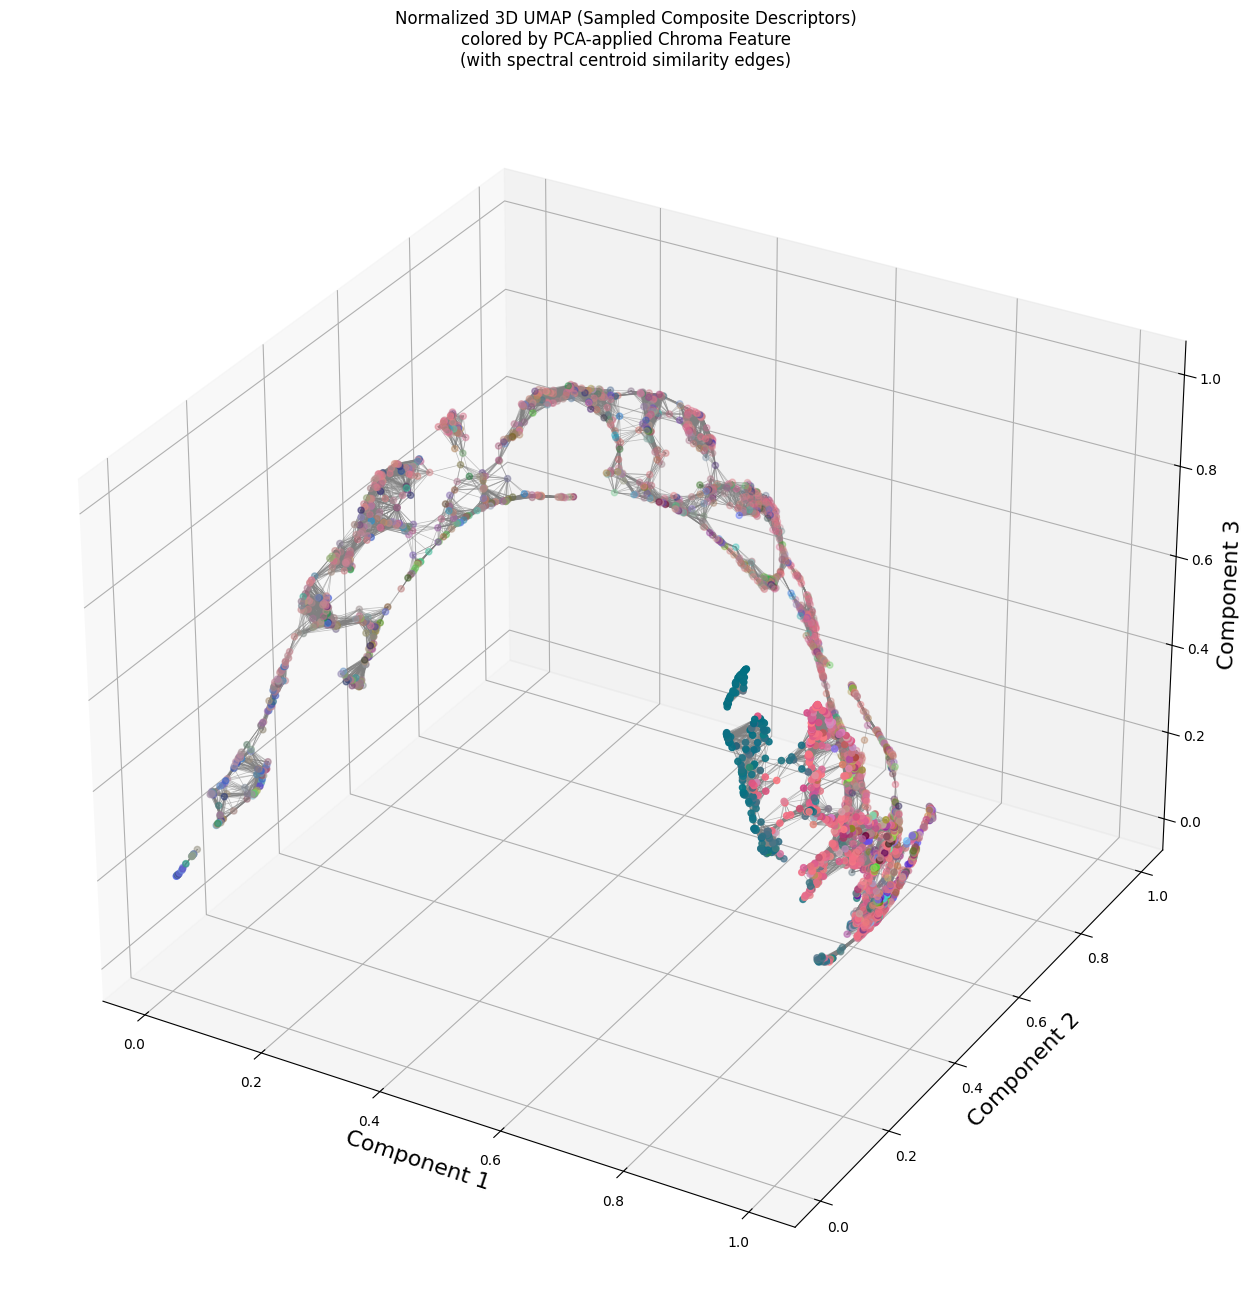

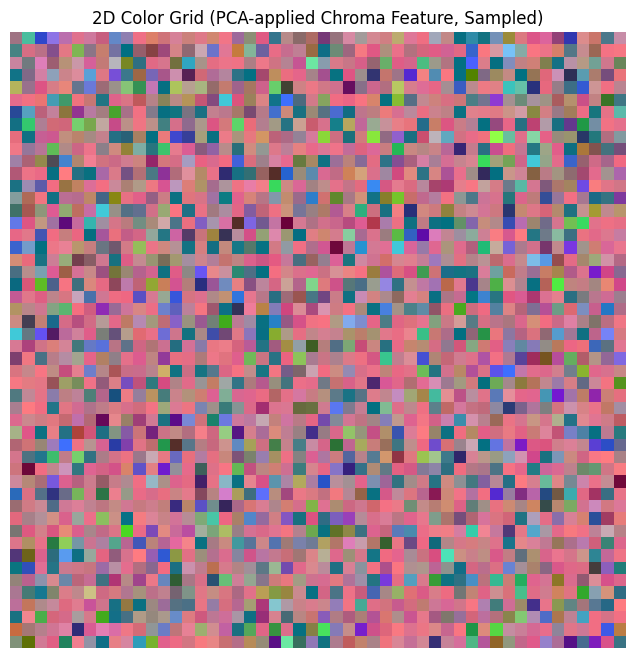

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import umap.umap_ as umap
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from tqdm import tqdm

# features_list 로드 (features_pkl_path 는 미리 정의했다고 가정)
try:
    with open(features_pkl_path, 'rb') as f:
        features_list = pickle.load(f)
except FileNotFoundError:
    print(f"File {features_pkl_path} not found.")
    features_list = []

# 복합 설명자 데이터셋 구축: 'mfccs_mean', 'spectral_centroid_mean', 'chroma_mean'
desc_keys = ['mfccs_mean', 'spectral_centroid_mean', 'chroma_mean']
descriptors_list = []
valid_indices = []  # 원본 features_list의 인덱스를 저장

for idx, feature_data in enumerate(tqdm(features_list, desc='Extracting composite descriptors')):
    combined = []
    valid = True
    for key in desc_keys:
        data = feature_data.get(key)
        if data is None:
            valid = False
            break
        arr = np.array(data)
        # 스칼라인 경우 1차원 배열로 변환
        if arr.ndim == 0:
            arr = np.array([arr])
        # 2차원인 경우 시간축 평균
        elif arr.ndim == 2:
            arr = np.mean(arr, axis=1)
        elif arr.ndim != 1:
            valid = False
            break
        combined.append(arr)
    if valid and len(combined) == len(desc_keys):
        composite_descriptor = np.concatenate(combined)
        descriptors_list.append(composite_descriptor)
        valid_indices.append(idx)
    else:
        print(f"Skipping feature_data index {idx}: missing or invalid descriptors.")

if not descriptors_list:
    print("No valid composite descriptor data found.")
else:
    # 모든 설명자 벡터의 길이가 동일한 경우만 선택
    valid_descriptors = []
    new_valid_indices = []
    target_len = None
    for i, vec in enumerate(descriptors_list):
        vec = np.array(vec)
        if vec.size == 0:
            continue
        if target_len is None:
            target_len = vec.shape[0]
        if vec.shape[0] == target_len:
            valid_descriptors.append(vec)
            new_valid_indices.append(valid_indices[i])
    valid_indices = np.array(new_valid_indices)
    descriptors_array = np.vstack(valid_descriptors)
    
    # --- 샘플링: 전체 설명자 중 일부(예: 2500개)를 무작위로 선택
    sample_count = 2500
    if len(descriptors_array) >= sample_count:
        sample_inds = np.random.choice(len(descriptors_array), sample_count, replace=False)
    else:
        sample_inds = np.arange(len(descriptors_array))
    descriptors_array_sample = descriptors_array[sample_inds]
    valid_indices_sample = valid_indices[sample_inds]
    
    # UMAP을 이용하여 샘플된 복합 설명자 데이터를 3차원으로 압축 
    umap_model = umap.UMAP(n_components=3, random_state=42, verbose=True, n_neighbors=15, min_dist=0.1, n_jobs=4)
    composite_umap_sample = umap_model.fit_transform(descriptors_array_sample)
    
    # UMAP 임베딩 결과 normalize (0~1)
    min_vals = composite_umap_sample.min(axis=0)
    max_vals = composite_umap_sample.max(axis=0)
    umap_normalized = (composite_umap_sample - min_vals) / (max_vals - min_vals)
    
    # 각 유닛의 크로마 벡터(12차원)를 valid_indices_sample를 통해 수집하고, 12차원 미만이면 패딩, 초과면 자르기
    chroma_all = []
    for i in valid_indices_sample:
        feature_data = features_list[i]
        chroma = np.array(feature_data.get('chroma_mean', []))
        if chroma.size < 12:
            chroma = np.pad(chroma, (0, 12 - chroma.size), mode='constant', constant_values=0)
        elif chroma.size > 12:
            chroma = chroma[:12]
        chroma_all.append(chroma)
    chroma_all = np.array(chroma_all)
    
    # PCA를 적용하여 12차원 크로마 벡터를 3차원 색상으로 축소 및 normalize
    pca = PCA(n_components=3)
    chroma_pca = pca.fit_transform(chroma_all)
    min_vals_pca = chroma_pca.min(axis=0)
    max_vals_pca = chroma_pca.max(axis=0)
    chroma_pca_normalized = (chroma_pca - min_vals_pca) / (max_vals_pca - min_vals_pca)
    
    # 스펙트럴 중심값(valid_indices_sample에 해당하는) 수집 및 normalize (0~1)
    spectral_values = []
    for i in valid_indices_sample:
        feature_data = features_list[i]
        spec = feature_data.get('spectral_centroid_mean', 0.0)
        spectral_values.append(spec)
    spectral_values = np.array(spectral_values)
    spec_min, spec_max = spectral_values.min(), spectral_values.max()
    spectral_norm = (spectral_values - spec_min) / (spec_max - spec_min)

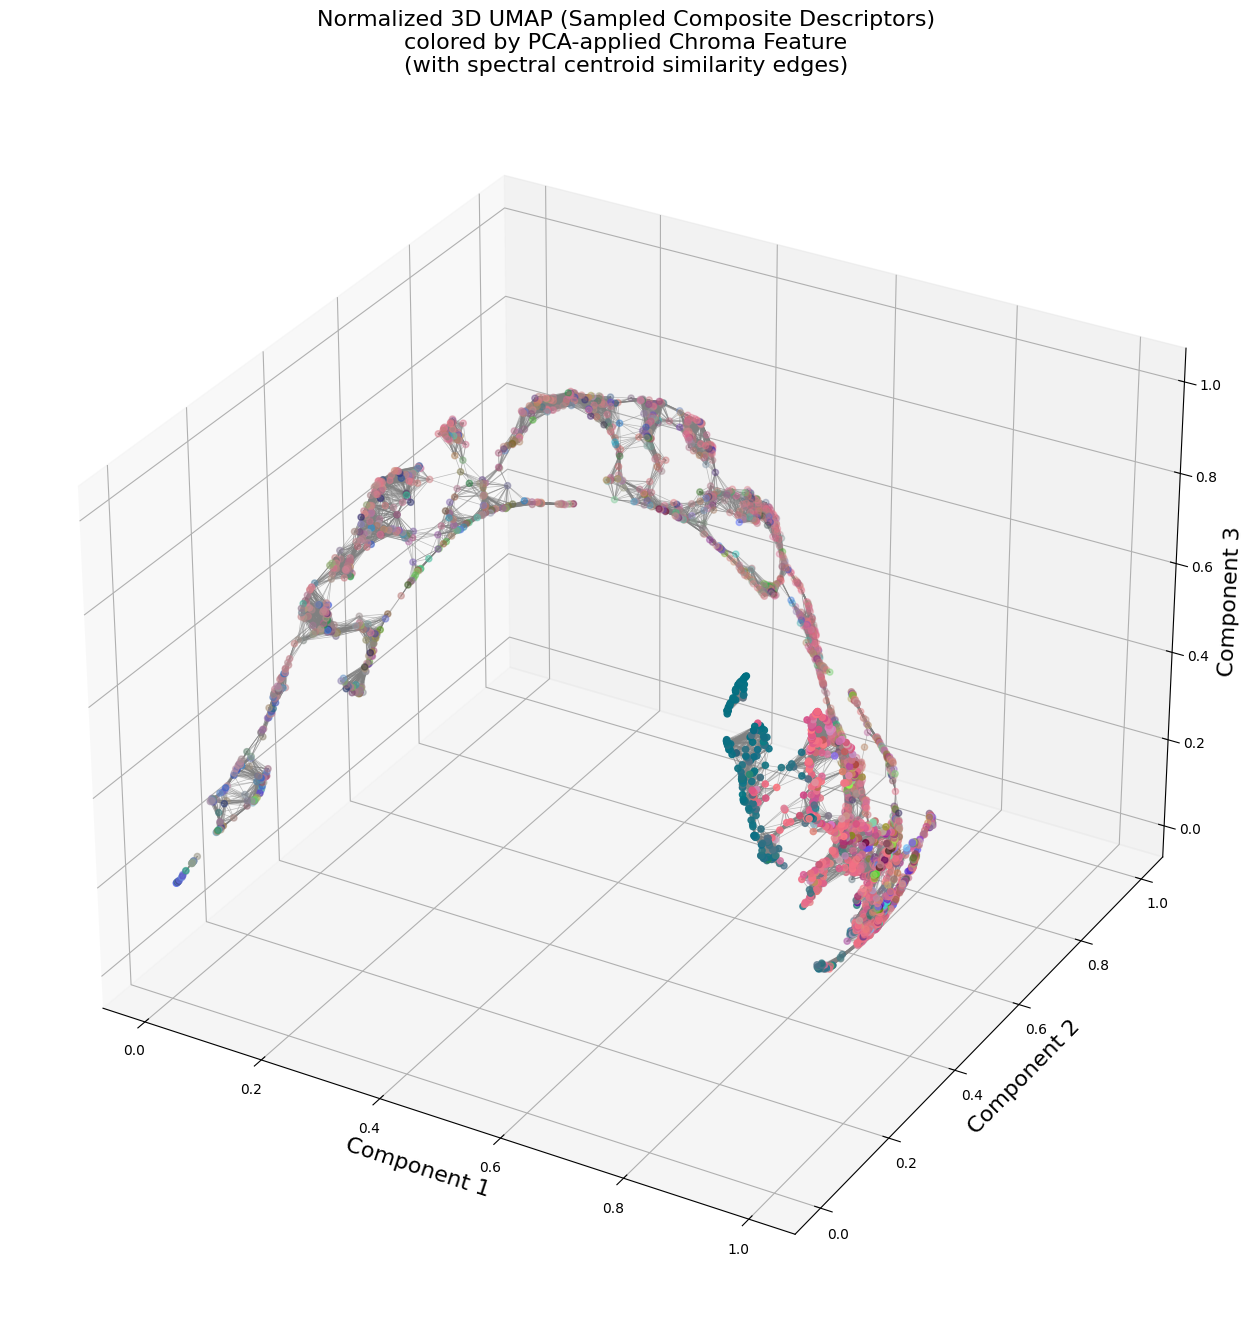

In [20]:
# 3D scatter plot: UMAP 결과에 PCA-applied 크로마 색상 적용
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
umap_normalized[:, 0],
umap_normalized[:, 1],
umap_normalized[:, 2],
c=chroma_pca_normalized,
marker='o'
)

# 선분 그리기: UMAP 공간상의 거리와 스펙트럴 중심값의 차이가 임계치 이하이면 선분으로 연결
threshold_umap = 0.05   # UMAP embedding 상의 임계치 (normalized 좌표)
threshold_spec = 0.04    # 스펙트럴 중심 정규값 차이 임계치
umap_dists = squareform(pdist(umap_normalized))
spec_diffs = squareform(pdist(spectral_norm.reshape(-1, 1), metric='cityblock'))

pairs = np.where((umap_dists < threshold_umap) & (spec_diffs < threshold_spec))
for i, j in zip(pairs[0], pairs[1]):
    if i < j:
        xs = [umap_normalized[i, 0], umap_normalized[j, 0]]
        ys = [umap_normalized[i, 1], umap_normalized[j, 1]]
        zs = [umap_normalized[i, 2], umap_normalized[j, 2]]
        ax.plot(xs, ys, zs, c='gray', alpha=0.5, linewidth=0.5)

ax.set_title('Normalized 3D UMAP (Sampled Composite Descriptors)\ncolored by PCA-applied Chroma Feature\n(with spectral centroid similarity edges)', fontsize=fontsize)
ax.set_xlabel('Component 1',fontsize=fontsize)
ax.set_ylabel('Component 2',fontsize=fontsize)
ax.set_zlabel('Component 3',fontsize=fontsize)
plt.show()

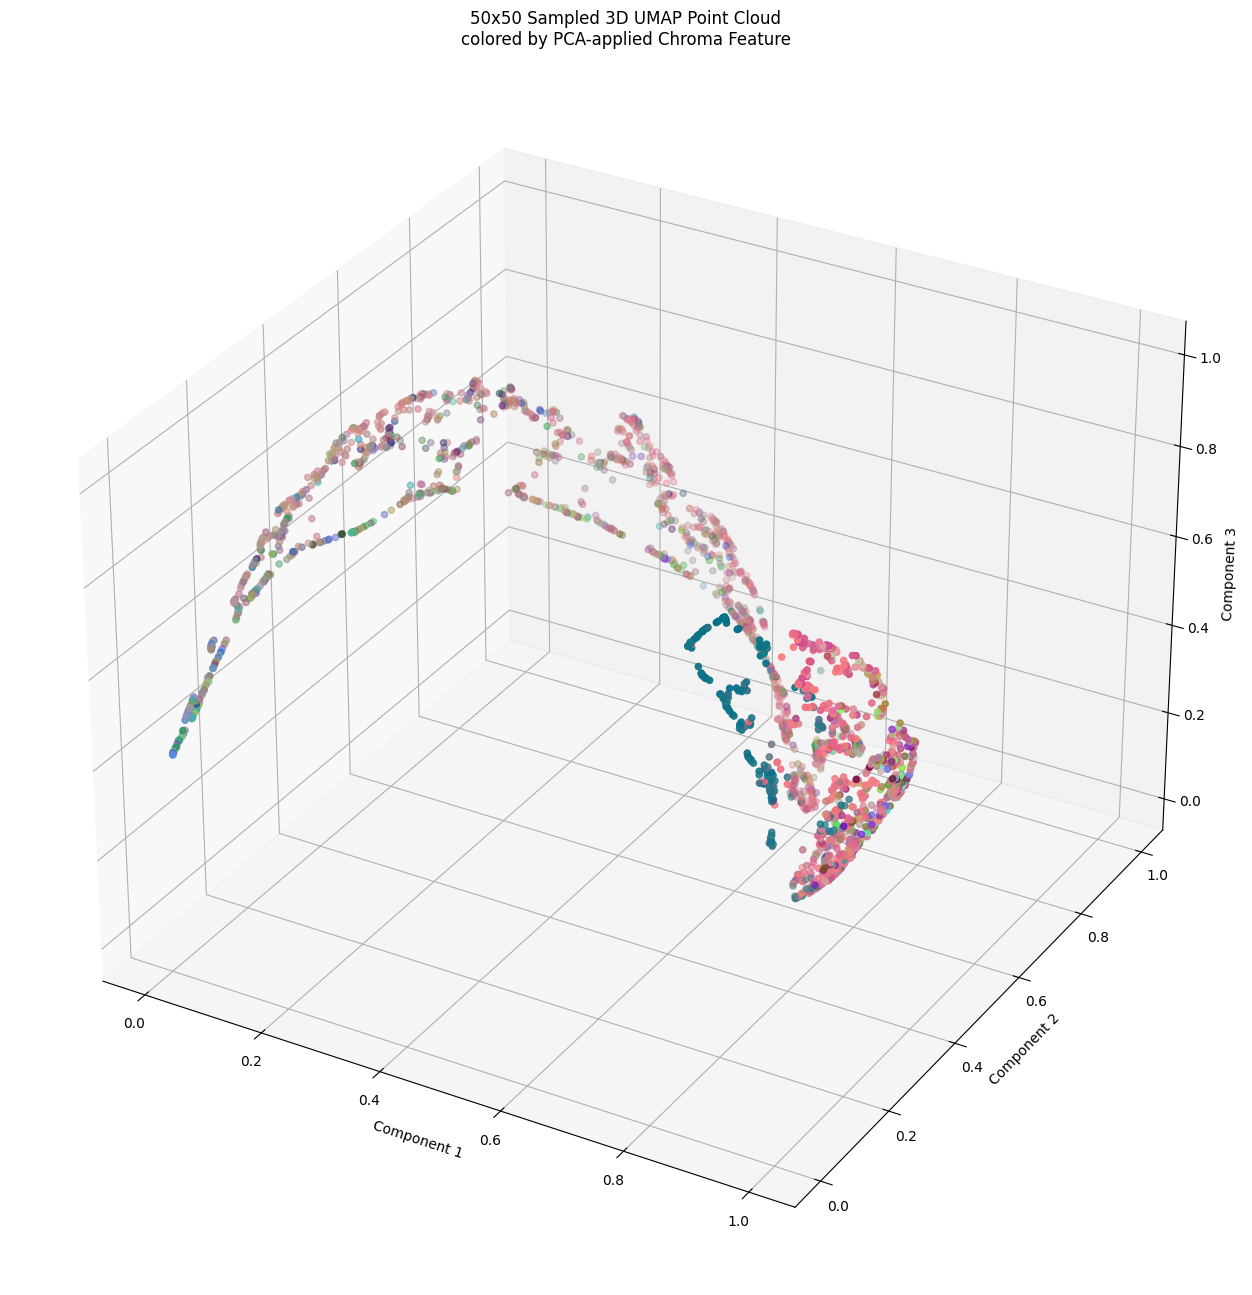

In [ ]:
    
    # ------------------------------------------------------------------------------
    # 기존 UMAP 임베딩 관련 코드 (생략)
    # ------------------------------------------------------------------------------
    # UMAP 임베딩 결과는 umap_normalized에 저장되어 있고, PCA-applied 색상은 chroma_pca_normalized에 저장됨

    # 3D point cloud를 50x50 (총 2500 points)로 샘플링하여 시각화
    grid_rows, grid_cols = 50, 50
    sample_count = grid_rows * grid_cols

    # 샘플링 모드를 선택: 'random' 또는 'block'
    sampling_mode = 'random'  # 또는 'block'

    if sampling_mode == 'random':
        # 무작위 샘플링 (재현을 위해 seed 설정)
        np.random.seed(4)
        if len(umap_normalized) >= sample_count:
            sampled_idx = np.random.choice(len(umap_normalized), sample_count, replace=False)
        else:
            sampled_idx = np.arange(len(umap_normalized))
        umap_sampled = umap_normalized[sampled_idx]
        colors_sampled = chroma_pca_normalized[sampled_idx]
    else:
        # block 샘플링: 사용자가 원하는 시작 인덱스를 지정 (예: 시작 인덱스 0부터 연속적으로 선택)
        start_idx = 0  # 필요에 따라 변경
        end_idx = start_idx + sample_count
        if end_idx <= len(umap_normalized):
            sampled_idx = np.arange(start_idx, end_idx)
        else:
            sampled_idx = np.arange(len(umap_normalized))
        umap_sampled = umap_normalized[sampled_idx]
        colors_sampled = chroma_pca_normalized[sampled_idx]

    # 3D 산점도에 샘플링된 포인트 클라우드 출력 (색상은 PCA-applied chroma 사용)
    fig = plt.figure(figsize=(16, 16))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(
        umap_sampled[:, 0],
        umap_sampled[:, 1],
        umap_sampled[:, 2],
        c=colors_sampled,
        marker='o'
    )
    ax.set_title('50x50 Sampled 3D UMAP Point Cloud\ncolored by PCA-applied Chroma Feature')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.show()


In [ ]:
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer

# FSD50k.eval.audio.pkl 불러오기
with open('./FSD50k.eval_audio.pkl', 'rb') as f:
    pkl_meta = pickle.load(f)

# 만약 pkl_meta가 dict가 아니라 리스트라면 keys 대신 리스트 자체를 사용
if isinstance(pkl_meta, dict):
    keys = pkl_meta.keys()
elif isinstance(pkl_meta, list):
    keys = pkl_meta
else:
    raise TypeError("pkl_meta 타입이 dict나 list가 아닙니다.")

# eval_clips_info_FSD50K.json 불러오기
with open('./FSD50K.metadata/eval_clips_info_FSD50K.json', 'r') as f:
    json_meta = json.load(f)

# pkl에 저장된 파일 ID와 JSON 메타 데이터의 ID를 매칭하여 태그를 코퍼스로 구성
corpus = []
file_ids = []
for key in keys:
    if key in json_meta:
        tags = json_meta[key].get('tags', [])
        if tags:
            corpus.append(' '.join(tags))
            file_ids.append(key)
    else:
        print(f"키 {key}는 JSON 메타데이터에 없습니다.")

# TF-IDF 벡터화 및 TSNE 2차원 임베딩
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X.toarray())

# tsne 임베딩 결과를 태그 문자열로 시각화
plt.figure(figsize=(12, 8))
for i, text in enumerate(corpus):
    plt.text(X_tsne[i, 0], X_tsne[i, 1], text, fontsize=8)
plt.title("TSNE 기반 FSD50K 태그 코퍼스 시각화")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.show()

TypeError: unhashable type: 'numpy.ndarray'

/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap

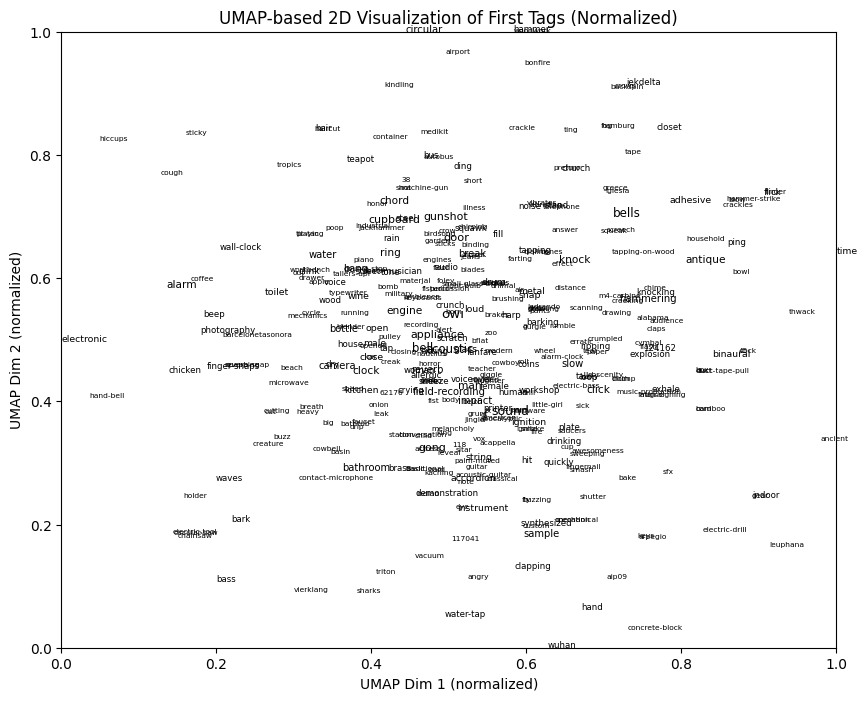

In [ ]:
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

# pkl 파일 불러오기 (각 요소는 dict: filename, mfccs_mean, spectral_centroid_mean, chroma_mean)
with open('./FSD50k.eval_audio_features.pkl', 'rb') as f:
    pkl_meta = pickle.load(f)

# JSON 메타데이터 불러오기
with open('./FSD50K.metadata/eval_clips_info_FSD50K.json', 'r') as f:
    json_meta = json.load(f)

# corpus 구성: pkl의 filename에서 ID 추출하여 JSON 메타데이터의 태그(들)를 연결
corpus = []
file_ids = []
for feature_data in pkl_meta:
    filename = feature_data.get('filename', '')
    if not filename:
        continue
    # "[ID]_onset_#.wav" 형식에서 ID 추출 (예: "399190")
    audio_id = str(filename).split('_')[0]
    if audio_id in json_meta:
        tags = json_meta[audio_id].get('tags', [])
        if tags:
            corpus.append(' '.join(tags))
            file_ids.append(audio_id)
    else:
        print(f"ID {audio_id} is not found in JSON metadata.")

# TF-IDF 벡터화: corpus를 수치화
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

# UMAP을 이용해 2차원으로 임베딩 (전체 피쳐 공간 축소)
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.3)
X_umap = umap_model.fit_transform(X.toarray())

# 100x100 (총 10,000) 포인트 무작위 샘플링 (메모리 문제 고려)
grid_size = 25
sample_count = grid_size * grid_size
if len(X_umap) >= sample_count:
    sample_inds = np.random.choice(len(X_umap), sample_count, replace=False)
else:
    sample_inds = np.arange(len(X_umap))
X_sample = X_umap[sample_inds]
corpus_sample = [corpus[i] for i in sample_inds]

# 각 데이터 포인트에서 첫 번째 태그만 추출하여 그룹화
first_token_indices = {}
for i, text in enumerate(corpus_sample):
    tokens = text.split()
    if tokens:  # 태그가 있는 경우
        first_token = tokens[0]
        first_token_indices.setdefault(first_token, []).append(i)

# 각 첫 번째 태그별 2차원 평균 좌표 계산
first_tag_coords = {}
for token, indices in first_token_indices.items():
    coords = X_sample[indices]  # 해당 데이터 포인트의 2D 임베딩 좌표
    mean_x = np.mean(coords[:, 0])
    mean_y = np.mean(coords[:, 1])
    first_tag_coords[token] = (mean_x, mean_y)

# 전체 첫 번째 태그 좌표의 중심 계산 후, 태그들을 중심에 더 가깝게 조정 (alpha: 조정 계수)
all_first_coords = np.array(list(first_tag_coords.values()))
center = np.mean(all_first_coords, axis=0)
alpha = 0.1  # 0~1 사이: 1이면 원래 좌표, 작을수록 중심으로 몰림
adjusted_first_coords = {}
for token, (x, y) in first_tag_coords.items():
    new_x = center[0] + alpha * (x - center[0])
    new_y = center[1] + alpha * (y - center[1])
    adjusted_first_coords[token] = (new_x, new_y)

# 조정된 좌표를 0~1 사이로 노멀라이제이션
all_adjusted = np.array(list(adjusted_first_coords.values()))
min_xy = np.min(all_adjusted, axis=0)
max_xy = np.max(all_adjusted, axis=0)
normalized_first_coords = {}
for token, (x, y) in adjusted_first_coords.items():
    norm_x = (x - min_xy[0]) / (max_xy[0] - min_xy[0])
    norm_y = (y - min_xy[1]) / (max_xy[1] - min_xy[1])
    normalized_first_coords[token] = (norm_x, norm_y)

# 각 태그의 등장 빈도(데이터 포인트 수)를 계산 (폰트 크기 조정을 위해)
first_token_counter = {token: len(indices) for token, indices in first_token_indices.items()}

# 모든 첫 번째 태그를 2D 공간에 시각화 (영문 타이틀)
plt.figure(figsize=(10, 8), dpi=100)
for token, (x, y) in normalized_first_coords.items():
    frequency = first_token_counter[token]
    fontsize = 4 + 2 * np.log(frequency + 1)  # 빈도에 따라 폰트 크기 조정
    plt.text(x, y, token, fontsize=fontsize)
plt.title("UMAP-based 2D Visualization of First Tags (Normalized)")
plt.xlabel("UMAP Dim 1 (normalized)")
plt.ylabel("UMAP Dim 2 (normalized)")
plt.show()